Loss (BCE) | Epoch  1 | Avg Loss: 164.78
Loss (BCE) | Epoch  2 | Avg Loss: 121.45
Loss (BCE) | Epoch  3 | Avg Loss: 114.53
Loss (BCE) | Epoch  4 | Avg Loss: 111.52
Loss (BCE) | Epoch  5 | Avg Loss: 109.78
Loss (MSE) | Epoch  1 | Avg Loss: 45.75
Loss (MSE) | Epoch  2 | Avg Loss: 35.05
Loss (MSE) | Epoch  3 | Avg Loss: 33.20
Loss (MSE) | Epoch  4 | Avg Loss: 32.28
Loss (MSE) | Epoch  5 | Avg Loss: 31.73

Pixel-wise Accuracy (BCE): 0.9615
Pixel-wise Accuracy (MSE): 0.9435


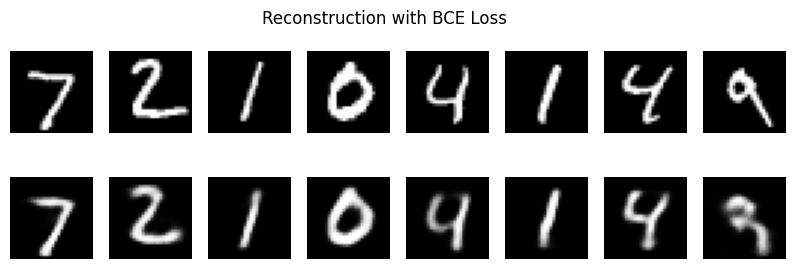

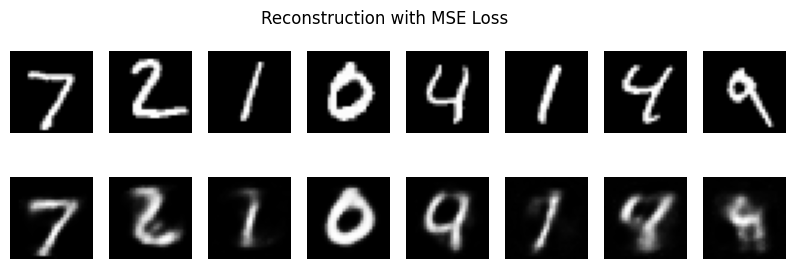

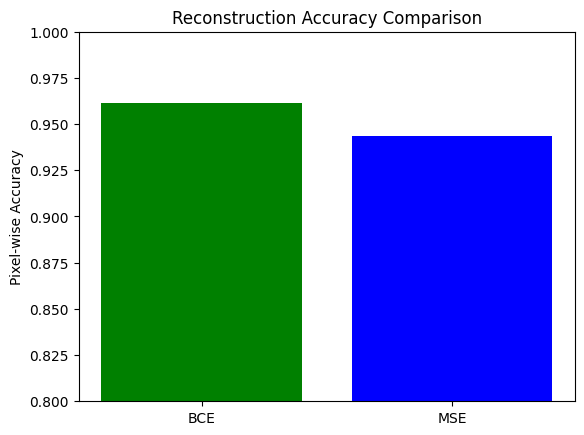

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

# VAE definition
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss Function
def loss_function(recon_x, x, mu, logvar, use_bce=True):
    x = x.view(-1, 784)
    if use_bce:
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    else:
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# Train VAE
def train(model, use_bce=True, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss = loss_function(recon, x, mu, logvar, use_bce)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Loss ({'BCE' if use_bce else 'MSE'}) | Epoch {epoch+1:2d} | Avg Loss: {total_loss / len(train_loader.dataset):.2f}")

# Pixel-wise Accuracy
def evaluate_accuracy(model):
    model.eval()
    total_acc = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, _, _ = model(x)
            bin_recon = (recon > 0.5).float()
            bin_x = (x > 0.5).float()
            acc = (bin_recon == bin_x.view(-1, 784)).float().mean()
            total_acc += acc.item()
    return total_acc / len(test_loader)

# Show Reconstructions
def show_reconstruction(model, title):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(test_loader))
        x = x[:8].to(device)
        recon, _, _ = model(x)
        recon = recon.view(-1, 1, 28, 28).cpu()
        x = x.cpu()

        plt.figure(figsize=(10, 3))
        for i in range(8):
            plt.subplot(2, 8, i+1)
            plt.imshow(x[i][0], cmap='gray')
            plt.axis('off')
            plt.subplot(2, 8, i+9)
            plt.imshow(recon[i][0], cmap='gray')
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

# ---- RUN EVERYTHING ----
vae_bce = VAE().to(device)
vae_mse = VAE().to(device)

train(vae_bce, use_bce=True)
train(vae_mse, use_bce=False)

acc_bce = evaluate_accuracy(vae_bce)
acc_mse = evaluate_accuracy(vae_mse)

print(f"\nPixel-wise Accuracy (BCE): {acc_bce:.4f}")
print(f"Pixel-wise Accuracy (MSE): {acc_mse:.4f}")

show_reconstruction(vae_bce, "Reconstruction with BCE Loss")
show_reconstruction(vae_mse, "Reconstruction with MSE Loss")

# Comparison plot
plt.figure()
plt.bar(["BCE", "MSE"], [acc_bce, acc_mse], color=["green", "blue"])
plt.ylabel("Pixel-wise Accuracy")
plt.title("Reconstruction Accuracy Comparison")
plt.ylim(0.8, 1.0)
plt.show()